In [1]:
%load_ext autoreload
%autoreload 2


In [1]:

from torch.utils.data import DataLoader
from pathlib import Path
import sys
import torch
from hist_colorizer.trainer_hist import TrainerHist
from hist_colorizer.model_hist import UNetHist
from hist_colorizer.dataset import ImagewoofColorizationDataset   # <-- tu dataset

# -----------------------------------------
# AJUSTÁ ESTAS RUTAS
# -----------------------------------------
DATA_DIR = Path("imagewoof2-160")
BATCH_SIZE = 8
EPOCHS = 5

train_ds = ImagewoofColorizationDataset(DATA_DIR, split="train")
val_ds   = ImagewoofColorizationDataset(DATA_DIR, split="val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)

ModuleNotFoundError: No module named 'hist_colorizer'

In [ ]:
model = UNetHist(K=32)

trainer = TrainerHist(model, lr=1e-4)

for epoch in range(1, EPOCHS+1):
    print(f"\n=== Epoch {epoch} ===")
    train_loss = trainer.train_epoch(train_loader)
    val_loss, val_psnr = trainer.validate_epoch(val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val PSNR:   {val_psnr:.2f} dB")

    # guardar modelo
    torch.save(model.state_dict(), f"hist_model_epoch{epoch}.pt")



=== Epoch 1 ===


Val: 100%|██████████| 492/492 [01:23<00:00,  5.89it/s]


Train Loss: 3.5206
Val Loss:   3.3841
Val PSNR:   22.38 dB

=== Epoch 2 ===


Val: 100%|██████████| 492/492 [01:27<00:00,  5.60it/s]


Train Loss: 3.2842
Val Loss:   3.2435
Val PSNR:   22.82 dB

=== Epoch 3 ===


...

Train Loss: 3.2484
Val Loss:   3.2232
Val PSNR:   22.84 dB

=== Epoch 4 ===


Val: 100%|██████████| 492/492 [01:22<00:00,  5.94it/s]


Train Loss: 3.2280
Val Loss:   3.1936
Val PSNR:   22.94 dB

=== Epoch 5 ===


Val: 100%|██████████| 492/492 [01:22<00:00,  5.97it/s]


Train Loss: 3.2142
Val Loss:   3.1921
Val PSNR:   23.02 dB


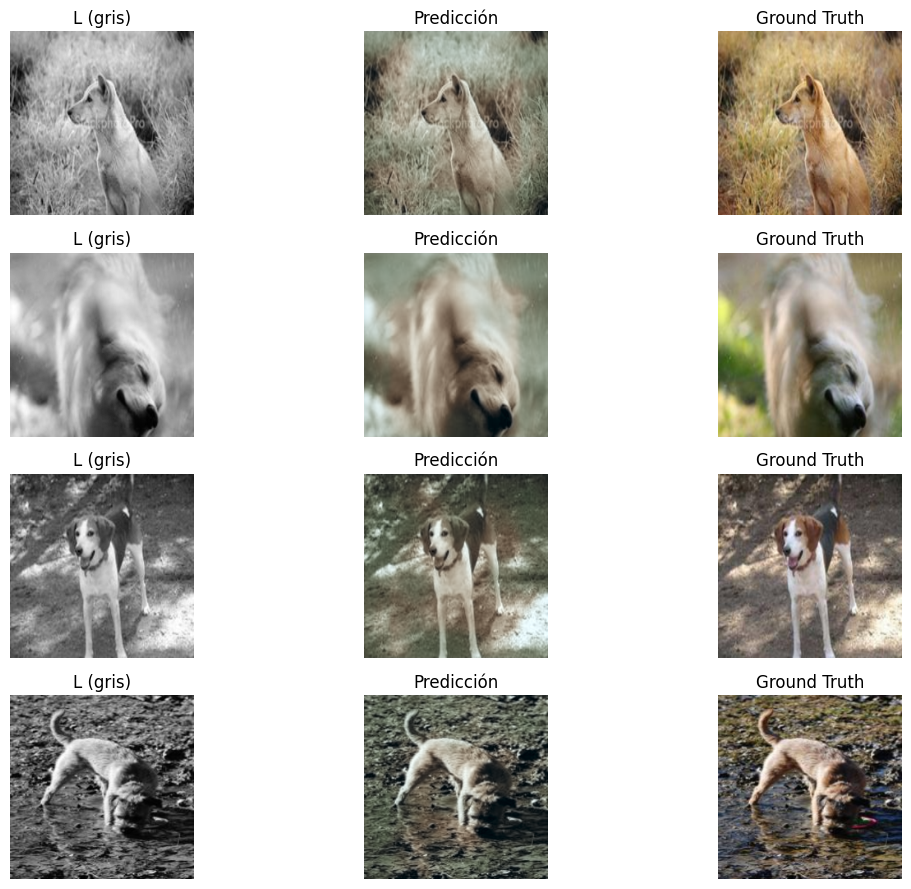

In [8]:
import torch
from torch.utils.data import DataLoader
from hist_colorizer.dataset import ImagewoofColorizationDataset
from hist_colorizer.model_hist import UNetHist
from hist_colorizer.utils_hist import show_colorization

# ------------ CONFIG ------------
CHECKPOINT = "hist_model_epoch5.pt"
DATA_DIR = "imagewoof2-160"
BATCH_SIZE = 4
# --------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

# cargar dataset
ds = ImagewoofColorizationDataset(DATA_DIR, split="val")
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

# cargar modelo
model = UNetHist(K=32).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))

# mostrar 4 imágenes
show_colorization(model, loader, device=device)
